# **Backtest Assignment**

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [39]:
import os
import sys

import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings('ignore')

from typing import Tuple, Dict, Any, List
from pathlib import Path
from IPython.display import display

from datetime import datetime, timedelta, time
import time

from tqdm.notebook import tqdm

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from prepare_data import load_and_process_data
from exchange_v2 import ExchangeSim, OpportunisticSpreadWidenMM, SWRParams, run_backtest, BTLogger

pd.options.display.float_format = '{:.6f}'.format
pd.set_option('display.max_columns', None)

In [3]:
# Symbol name
asset_name= 'HYPEUSDT'
quotes_df, trades_df, events_df = load_and_process_data(asset_name)

In [4]:
#quotes_df.head()

In [5]:
# print("n_quotes:", len(quotes_df), "n_trades:", len(trades_df), "n_events:", len(events_df))
# print("event types:\n", events_df["etype"].value_counts())

# # monotonic time
# assert events_df["ts_us"].is_monotonic_increasing

# # check any identical timestamps (normal in crypto feeds)
# same_ts = (events_df["ts_us"].diff() == 0).sum()
# print("same-timestamp transitions:", int(same_ts))

## Running the skeleton

In [13]:
sim = ExchangeSim(
    asset_name='HYPE',
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,      # start with 5ms; tune later
    depth_levels=5,
)

# Example: place one passive buy at best_bid, then run
# We'll place after first quote arrives (so book is valid)

placed = False
for ev in events_df.itertuples(index=False):
    if ev.etype == "quote":
        row = quotes_df.iloc[ev.qidx]
        sim.on_quote(row)
        if (not placed) and sim.book.is_valid():
            oid = sim.place_limit("buy", sim.book.snap.best_bid, qty=0.01, ts_us=ev.ts_us)
            placed = True

    else:  # trade
        trow = trades_df.iloc[ev.tidx]
        sim.on_trade(trow, ts_us=ev.ts_us)

# Inspect
print("pos:", sim.pos, "cash:", sim.cash, "n_fills:", len(sim.fills), "active:", len(sim.active_ids))
pd.DataFrame([f.__dict__ for f in sim.fills]).head()

pos: 0.01 cash: -0.40831164600000003 n_fills: 1 active: 0


,ts_us,order_id,side,price,qty,fee
0,1754006402199000,1,buy,40.823000,0.010000,0.000082


## **Run the backtest**

In [25]:
params = SWRParams()

sim = ExchangeSim(
    asset_name="HYPE",
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,
    depth_levels=5,
)

strategy = OpportunisticSpreadWidenMM(params)

eq = run_backtest(events_df, quotes_df, trades_df, sim, strategy)

fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)
fills_df

fills: 26 final pos: 8.969999999999999 final cash: -383.600407174


,ts_us,order_id,side,price,qty,fee
0,1754006462416000,1,buy,40.881000,0.130000,0.001063
1,1754006462416000,1,buy,40.881000,0.130000,0.001063
2,1754006462416000,1,buy,40.881000,2.740000,0.022403
3,1754007113595000,3,buy,40.670000,2.460000,0.020010
4,1754007113595000,3,buy,40.670000,0.540000,0.004392
5,1754007121224000,5,buy,40.641000,3.000000,0.024385
6,1754009518761000,9,buy,40.427000,3.000000,0.024256
7,1754009839353000,11,buy,40.873000,3.000000,0.024524
8,1754010591843000,15,sell,40.978000,0.130000,0.001065
9,1754010591856000,15,sell,40.978000,2.440000,0.019997


In [20]:
# all orders ever created
orders_df = pd.DataFrame(
    {oid: vars(o) for oid, o in sim.orders.items()}
).T

orders_df[["order_id", "side", "price", "qty", "is_active", "is_done"]]

,order_id,side,price,qty,is_active,is_done
1,1,buy,40.881000,3.000000,False,True
2,2,sell,40.887000,3.000000,False,True
3,3,buy,40.670000,3.000000,False,True
4,4,sell,40.676000,3.000000,False,True
5,5,buy,40.641000,3.000000,False,True
...,...,...,...,...,...,...
79,79,sell,36.890000,3.000000,False,True
80,80,buy,36.820000,3.000000,False,True
81,81,sell,36.827000,3.000000,False,True
82,82,buy,36.974000,3.000000,False,True


## **Run backtest with Logge: USE THIS ONE**

In [68]:
# After implementing log
params = SWRParams()

sim = ExchangeSim(
    asset_name="HYPE",
    tick_size=0.001,
    maker_fee=0.0002,
    taker_fee=0.0005,
    latency_us=5_000,
    depth_levels=5,
)
logger = BTLogger()

strategy = OpportunisticSpreadWidenMM(params, logger=logger)
eq = run_backtest(events_df, quotes_df, trades_df, sim, strategy, logger)
log_df = logger.to_df()

In [36]:
#log_df.head()

In [37]:
#log_df["reason"].value_counts()

In [38]:
#log_df["action"].value_counts()

In [84]:
display(log_df.query("action == 'FILL'")["fill_source"].value_counts())

fill_source
trade_through    26
quote_cross      18
Name: count, dtype: int64

In [85]:
display(log_df.query("action == 'PLACE'")[["ts","side","order_id","reason","price","qty"]].head())

,ts,side,order_id,reason,price,qty
2,2025-08-01 00:01:02.405000+00:00,buy,1.000000,enter_regime,40.881000,3.000000
3,2025-08-01 00:01:02.405000+00:00,sell,2.000000,enter_regime,40.887000,3.000000
150,2025-08-01 00:11:53.582000+00:00,buy,3.000000,enter_regime,40.670000,3.000000
151,2025-08-01 00:11:53.582000+00:00,sell,4.000000,enter_regime,40.676000,3.000000
165,2025-08-01 00:12:01.146000+00:00,buy,5.000000,enter_regime,40.641000,3.000000


In [86]:
display(log_df.query("action == 'CANCEL'")[["ts","side","order_id","reason"]].head())

,ts,side,order_id,reason
10,2025-08-01 00:01:02.456000+00:00,buy,1.000000,tox_fail
11,2025-08-01 00:01:02.456000+00:00,sell,2.000000,tox_fail
157,2025-08-01 00:11:53.633000+00:00,buy,3.000000,tox_fail
158,2025-08-01 00:11:53.633000+00:00,sell,4.000000,tox_fail
569,2025-08-01 00:46:03.535000+00:00,buy,7.000000,tox_fail


In [97]:
fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)
fills_df.head()

fills: 14 final pos: 9.06 final cash: -392.8595368080001


,ts_us,order_id,side,price,qty,fee,source
0,1754009518761000,1,buy,40.427000,3.000000,0.024256,quote_cross
1,1754009839353000,3,buy,40.873000,3.000000,0.024524,quote_cross
2,1754010564475000,7,buy,41.020000,3.000000,0.024612,quote_cross
3,1754010591843000,10,sell,40.978000,0.130000,0.001065,trade_through
4,1754010591856000,10,sell,40.978000,2.440000,0.019997,trade_through


In [98]:
# all orders ever created
orders_df = pd.DataFrame(
    {oid: vars(o) for oid, o in sim.orders.items()}
).T

n_orders = orders_df.shape[0]
n_filled_orders = fills_df["order_id"].nunique()

fill_rate = n_filled_orders / n_orders
print("Fill rate:", fill_rate)

Fill rate: 0.22


In [99]:
fills_df = fills_df.sort_values("ts_us")

fills_df["signed_qty"] = np.where(
    fills_df["side"] == "buy",
    fills_df["qty"],
    -fills_df["qty"]
)

fills_df["signed_notional"] = np.where(
    fills_df["side"] == "buy",
    -fills_df["price"] * fills_df["qty"],
    fills_df["price"] * fills_df["qty"]
)

fills_df["pnl_contrib"] = fills_df["signed_notional"] - fills_df["fee"]
fills_df["cum_pnl"] = fills_df["pnl_contrib"].cumsum()
win_rate = (fills_df["pnl_contrib"] > 0).mean()
win_rate

np.float64(0.5)

In [53]:
log_df.groupby("action")["event_i"].count() / len(events_df)

action
CANCEL       0.000019
CANCEL_ALL   0.001294
FILL         0.000015
GATE         0.000027
PLACE        0.000039
REGIME       0.001763
Name: event_i, dtype: float64

# **Log Analysis**

**Step 1 — Build an “episode table” (each regime window)**

We want to group everything between enter_regime and exit_regime into episodes so we can see what happened per opportunity.

What to look for:

- Are episodes super short (like tens of ms)? → regime threshold chatter
- Are many episodes long but we don’t place? → toxicity filter too strict / tight spread

In [69]:
ld = log_df.copy().sort_values(["ts_us","event_i"]).reset_index(drop=True)

# mark regime flips
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][
    ["ts_us","event_i","reason","spread_bps","med_bps","pos"]
].copy()

# pair enter->exit
enters = reg[reg.reason=="enter_regime"].reset_index(drop=True)
exits  = reg[reg.reason=="exit_regime"].reset_index(drop=True)

# if counts mismatch (end of day), align by index min len
m = min(len(enters), len(exits))
episodes = pd.DataFrame({
    "enter_ts_us": enters.loc[:m-1, "ts_us"].values,
    "enter_event_i": enters.loc[:m-1, "event_i"].values,
    "enter_spread_bps": enters.loc[:m-1, "spread_bps"].values,
    "enter_med_bps": enters.loc[:m-1, "med_bps"].values,
    "enter_pos": enters.loc[:m-1, "pos"].values,
    "exit_ts_us": exits.loc[:m-1, "ts_us"].values,
    "exit_event_i": exits.loc[:m-1, "event_i"].values,
})

episodes["dur_ms"] = (episodes["exit_ts_us"] - episodes["enter_ts_us"]) / 1000.0
#episodes.describe()

In [41]:
# # Randomly pick cases to see the pattern
# # Already done and fix. But this code is cool
# enter_idx = log_df.index[log_df.reason=="enter_regime"].to_numpy()
# sample = np.random.choice(enter_idx, size=5, replace=False)

# for idx in sample:
#     print("----")
#     display(log_df.loc[idx, ["ts","event_i","spread_bps","med_bps","pos"]])
#     display(log_df.iloc[idx:idx+10][["ts","event_i","etype","action","reason","pos"]])

In [42]:
display(log_df["action"].value_counts())
display(log_df[log_df.action=="REGIME"]["reason"].value_counts())

action
CANCEL_ALL    7752
REGIME        5229
PLACE           50
GATE            22
CANCEL          17
FILL            14
Name: count, dtype: int64

reason
exit_suppressed_min_hold    2611
enter_regime                1309
exit_regime                 1309
Name: count, dtype: int64

In [70]:
reg = log_df[(log_df.action=="REGIME")][["ts_us","reason","event_i"]].copy()
reg["delta_ms"] = reg["ts_us"].diff() / 1000
display(reg.head(5))

,ts_us,reason,event_i,delta_ms
0,1754006462405000,enter_regime,4187,NaN
3,1754006462456000,exit_suppressed_min_hold,4199,51.000000
6,1754006462509000,exit_suppressed_min_hold,4200,53.000000
9,1754006462561000,exit_regime,4201,52.000000
10,1754006546214000,enter_regime,7967,83653.000000


In [71]:
reg2 = log_df[(log_df.action=="REGIME") & (log_df.reason.isin(["enter_regime","exit_regime"]))] \
        .sort_values(["ts_us","event_i"])

episodes = []
open_enter = None
for r in reg2.itertuples(index=False):
    if r.reason == "enter_regime":
        if open_enter is None:
            open_enter = r
    else:
        if open_enter is not None:
            episodes.append({
                "enter_ts_us": open_enter.ts_us,
                "exit_ts_us": r.ts_us,
                "dur_ms": (r.ts_us - open_enter.ts_us)/1000,
                "enter_event_i": open_enter.event_i,
                "exit_event_i": r.event_i,
            })
            open_enter = None
episodes = pd.DataFrame(episodes)

display(episodes["dur_ms"].describe())
display((episodes["dur_ms"] <= 300).mean())   # optional quick view

count   1309.000000
mean     156.742552
std        5.055974
min      152.000000
25%      154.000000
50%      155.000000
75%      158.000000
max      222.000000
Name: dur_ms, dtype: float64

np.float64(1.0)

In [72]:
tox = log_df.query("action=='CANCEL_ALL' and reason=='tox_fail'")
tox[["tox_count","tox_total","tox_net"]].describe()

,tox_count,tox_total,tox_net
count,3861.000000,3861.000000,3861.000000
mean,67.543901,850.864587,-234.213605
std,104.706204,2207.014831,2136.965238
min,2.000000,10.530000,-36474.530000
25%,24.000000,113.530000,-232.540000
50%,38.000000,252.160000,-34.370000
75%,65.000000,642.020000,158.700000
max,1579.000000,40041.210000,13951.080000


In [73]:
reg = log_df[log_df.action=="REGIME"][["ts_us","reason","event_i"]].copy()
reg["delta_ms"] = reg["ts_us"].diff() / 1000
reg.head(20)

,ts_us,reason,event_i,delta_ms
0,1754006462405000,enter_regime,4187,NaN
3,1754006462456000,exit_suppressed_min_hold,4199,51.000000
6,1754006462509000,exit_suppressed_min_hold,4200,53.000000
9,1754006462561000,exit_regime,4201,52.000000
10,1754006546214000,enter_regime,7967,83653.000000
13,1754006546265000,exit_suppressed_min_hold,7997,51.000000
16,1754006546316000,exit_suppressed_min_hold,7998,51.000000
19,1754006546368000,exit_regime,7999,52.000000
20,1754006646733000,enter_regime,10455,100365.000000
23,1754006646786000,exit_suppressed_min_hold,10456,53.000000


In [74]:
reg = log_df[log_df.action=="REGIME"][["ts_us","reason","event_i"]].copy()
reg["delta_ms"] = reg["ts_us"].diff() / 1000
reg.head(20)

,ts_us,reason,event_i,delta_ms
0,1754006462405000,enter_regime,4187,NaN
3,1754006462456000,exit_suppressed_min_hold,4199,51.000000
6,1754006462509000,exit_suppressed_min_hold,4200,53.000000
9,1754006462561000,exit_regime,4201,52.000000
10,1754006546214000,enter_regime,7967,83653.000000
13,1754006546265000,exit_suppressed_min_hold,7997,51.000000
16,1754006546316000,exit_suppressed_min_hold,7998,51.000000
19,1754006546368000,exit_regime,7999,52.000000
20,1754006646733000,enter_regime,10455,100365.000000
23,1754006646786000,exit_suppressed_min_hold,10456,53.000000


### **To fully understand the algorithm**

**Q1. When do we trade vs skip?**

In [75]:
# 1) regime entries
regimes = log_df.query("action=='REGIME' and reason=='enter_regime'").copy()

# 2) one PLACE per event_i? (in your system you might PLACE 2 sides same event_i)
# Keep all places, but also create an "any place" indicator per event_i.
places = log_df.query("action=='PLACE'").copy()

# 3) For "why skipped", grab the FIRST blocking reason after enter within the same regime window.
# We'll approximate: look at logs on the same event_i (immediate) OR next few events.
# (This is usually enough because your tox_fail/tight_spread triggers right away.)
block_actions = ["CANCEL_ALL", "GATE", "CANCEL"]
blocks = log_df[log_df["action"].isin(block_actions)].copy()

# Helper: for each enter event_i, find earliest blocking row within a small lookahead window.
LOOKAHEAD_EVENTS = 50  # tweak if needed

# Keep just the minimal columns we care about
reg0 = regimes[["ts_us","ts","event_i","spread_bps","med_bps","pos",
               "enter_thr_bps","enter_excess_bps"]].copy()
for c in ["enter_thr_bps","enter_excess_bps"]:
    if c not in reg0.columns:
        reg0[c] = np.nan

# Index blocks by event_i for fast lookup
blocks_small = blocks[["ts_us","ts","event_i","action","reason","tox_count","tox_total","tox_net","gated_side"]].copy()
for c in ["tox_count","tox_total","tox_net","gated_side"]:
    if c not in blocks_small.columns:
        blocks_small[c] = np.nan

# Build mapping from enter row -> first block in [event_i, event_i+LOOKAHEAD]
blocks_sorted = blocks_small.sort_values(["event_i","ts_us"], kind="mergesort")

def first_block_after(ei: int):
    m = blocks_sorted[(blocks_sorted.event_i >= ei) & (blocks_sorted.event_i <= ei + LOOKAHEAD_EVENTS)]
    if len(m) == 0:
        return None
    return m.iloc[0]

first_blocks = []
for ei in reg0["event_i"].to_numpy():
    fb = first_block_after(int(ei))
    first_blocks.append(fb.to_dict() if fb is not None else {})

fb_df = pd.DataFrame(first_blocks)
fb_df = fb_df.add_prefix("block_")

# Merge in "did we place at least one order?"
placed_any = places.groupby("event_i").size().rename("n_places").reset_index()
reg = reg0.merge(placed_any, on="event_i", how="left")
reg["n_places"] = reg["n_places"].fillna(0).astype(int)
reg["did_trade"] = reg["n_places"] > 0

# attach first block info (approx reason for skip / behavior right after enter)
reg = pd.concat([reg.reset_index(drop=True), fb_df.reset_index(drop=True)], axis=1)

# A nicer "skip_reason" field
reg["skip_reason"] = np.where(
    reg["did_trade"], 
    "traded",
    reg.get("block_reason", pd.Series([np.nan]*len(reg))).fillna("no_block_found")
)

# Show a compact view
cols = [
    "ts","event_i","spread_bps","med_bps","enter_thr_bps","enter_excess_bps","pos",
    "did_trade","n_places","skip_reason",
    "block_action","block_reason","block_tox_count","block_tox_total","block_tox_net","block_gated_side"
]
cols = [c for c in cols if c in reg.columns]
reg[cols].head(5)

,ts,event_i,spread_bps,med_bps,enter_thr_bps,enter_excess_bps,pos,did_trade,n_places,skip_reason,block_action,block_reason,block_tox_count,block_tox_total,block_tox_net,block_gated_side
0,2025-08-01 00:01:02.405000+00:00,4187,1.956756,0.244565,1.711952,0.244804,0.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
1,2025-08-01 00:02:26.214000+00:00,7967,1.957043,0.244717,1.713020,0.244023,0.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
2,2025-08-01 00:04:06.733000+00:00,10455,1.956373,0.244508,1.711554,0.244819,0.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
3,2025-08-01 00:05:11.592000+00:00,13138,2.447381,0.244807,1.713649,0.733732,0.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
4,2025-08-01 00:06:35.148000+00:00,16318,2.198420,0.244352,1.710467,0.487953,0.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN


In [76]:
print("Regime entries:", len(reg))
print("Traded regimes:", reg["did_trade"].sum(), f"({reg['did_trade'].mean():.2%})")
print("\nSkip reasons (approx):")
display(reg.loc[~reg.did_trade, "skip_reason"].value_counts().head(20))

Regime entries: 1309
Traded regimes: 24 (1.83%)

Skip reasons (approx):


skip_reason
tox_fail    1285
Name: count, dtype: int64

In [77]:
feat_cols = ["spread_bps","med_bps","enter_thr_bps","enter_excess_bps","pos",
             "block_tox_count","block_tox_total","block_tox_net"]
feat_cols = [c for c in feat_cols if c in reg.columns]

summary = reg.groupby("did_trade")[feat_cols].describe().T
summary[:24]

did_trade                 False     True 
spread_bps    count 1285.000000 24.000000
              mean     2.806686  1.995997
              std      1.474129  0.256822
              min      1.690964  1.686117
              25%      2.017909  1.769550
              50%      2.395624  1.973891
              75%      3.121667  2.140927
              max     31.840347  2.645223
med_bps       count 1285.000000 24.000000
              mean     0.273649  0.251989
              std      0.070062  0.010096
              min      0.240399  0.240845
              25%      0.250097  0.244065
              50%      0.256815  0.248055
              75%      0.267062  0.257086
              max      0.953621  0.270948
enter_thr_bps count 1285.000000 24.000000
              mean     1.915541  1.763926
              std      0.490431  0.070671
              min      1.682793  1.685914
              25%      1.750678  1.708453
              50%      1.797707  1.736385
              75%      1.869433  1.799604
              max      6.675347  1.896633

In [78]:
if "enter_excess_bps" in reg.columns:
    display(reg.groupby("did_trade")["enter_excess_bps"].describe())

,count,mean,std,min,25%,50%,75%,max
did_trade,,,,,,,,
False,1285.000000,0.891145,1.284210,0.000000,0.249500,0.507009,1.078472,25.709884
True,24.000000,0.232071,0.235811,0.000000,0.000195,0.246940,0.267240,0.793787


In [79]:
# Among skipped regimes, how many were immediately blocked by tox?
mask_skip = ~reg["did_trade"]
print("Skipped regimes:", mask_skip.sum())
print("Skipped due to tox_fail (approx):",
      (reg.loc[mask_skip, "skip_reason"] == "tox_fail").sum())

Skipped regimes: 1285
Skipped due to tox_fail (approx): 1285


In [80]:
# Count actions per episode window
def count_in_window(df, e0, e1, action=None):
    m = (df.event_i >= e0) & (df.event_i <= e1)
    if action is not None:
        m &= (df.action == action)
    return int(m.sum())

ep = episodes.copy()

ep["n_place"] = [count_in_window(log_df, a, b, "PLACE") for a,b in zip(ep.enter_event_i, ep.exit_event_i)]
ep["n_fill"]  = [count_in_window(log_df, a, b, "FILL")  for a,b in zip(ep.enter_event_i, ep.exit_event_i)]
ep["n_cancel_all"] = [count_in_window(log_df, a, b, "CANCEL_ALL") for a,b in zip(ep.enter_event_i, ep.exit_event_i)]

display(ep[["dur_ms","n_place","n_fill","n_cancel_all"]].describe())
display(ep.sort_values("n_fill", ascending=False).head(10))

,dur_ms,n_place,n_fill,n_cancel_all
count,1309.000000,1309.000000,1309.000000,1309.000000
mean,156.742552,0.038197,0.010695,5.922078
std,5.055974,0.303005,0.129248,0.578707
min,152.000000,0.000000,0.000000,0.000000
25%,154.000000,0.000000,0.000000,6.000000
50%,155.000000,0.000000,0.000000,6.000000
75%,158.000000,0.000000,0.000000,6.000000
max,222.000000,4.000000,3.000000,6.000000


,enter_ts_us,exit_ts_us,dur_ms,enter_event_i,exit_event_i,n_place,n_fill,n_cancel_all
108,1754010591828000,1754010591983000,155.000000,166954,166973,2,3,4
1061,1754077800131000,1754077800286000,155.000000,2476051,2476107,1,2,4
264,1754028003771000,1754028003926000,155.000000,645865,645875,2,1,3
64,1754009518708000,1754009518867000,159.000000,113097,113122,2,1,2
84,1754009839302000,1754009839458000,156.000000,130039,130042,2,1,2
107,1754010564319000,1754010564475000,156.000000,166055,166058,4,1,0
190,1754016151665000,1754016151824000,159.000000,338498,338501,2,1,1
1076,1754078375215000,1754078375371000,156.000000,2498585,2498588,2,1,2
159,1754013001670000,1754013001824000,154.000000,251552,251555,4,1,0
144,1754011885879000,1754011886035000,156.000000,213925,213928,2,1,2


In [81]:
reg["did_trade"].mean()

np.float64(0.01833460656990069)

In [82]:
reg.loc[~reg.did_trade, "skip_reason"].value_counts().head(10)

skip_reason
tox_fail    1285
Name: count, dtype: int64

In [83]:
ep[["dur_ms","n_place","n_fill","n_cancel_all"]].describe()

,dur_ms,n_place,n_fill,n_cancel_all
count,1309.000000,1309.000000,1309.000000,1309.000000
mean,156.742552,0.038197,0.010695,5.922078
std,5.055974,0.303005,0.129248,0.578707
min,152.000000,0.000000,0.000000,0.000000
25%,154.000000,0.000000,0.000000,6.000000
50%,155.000000,0.000000,0.000000,6.000000
75%,158.000000,0.000000,0.000000,6.000000
max,222.000000,4.000000,3.000000,6.000000


**Step 2 — Per-episode action summary (why we didn’t trade)**

Interpretation rules:
- places=0 in many episodes → you’re in regime but blocked (tox_fail or tight spread)
- places>0 but fills=0 → either TTL too short, or fill engine too strict, or market didn’t trade-through
- Many CANCEL_ALL tox_fail inside episodes → toxicity filter dominates; you’re “too safe”

This tells us which knob matters first.

In [84]:
def summarize_episode(ep):
    sub = ld[(ld.ts_us>=ep.enter_ts_us) & (ld.ts_us<=ep.exit_ts_us)]
    out = {
        "places": int((sub.action=="PLACE").sum()),
        "cancels": int((sub.action=="CANCEL").sum()),
        "fills": int((sub.action=="FILL").sum()),
        "cancel_all": int((sub.action=="CANCEL_ALL").sum()),
        "gate": int((sub.action=="GATE").sum()),
    }
    # most common cancel_all reason
    if out["cancel_all"]>0:
        out["top_block"] = sub[sub.action=="CANCEL_ALL"]["reason"].value_counts().idxmax()
    else:
        out["top_block"] = None
    return pd.Series(out)

ep_stats = episodes.apply(summarize_episode, axis=1)
episodes2 = pd.concat([episodes, ep_stats], axis=1)

episodes2["fill_rate_ep"] = episodes2["fills"] / episodes2["places"].replace(0,np.nan)
#episodes2.sort_values(["fills","places"], ascending=False).head(20)
episodes2.sort_values(["fills","places"], ascending=False).head(5)

,enter_ts_us,exit_ts_us,dur_ms,enter_event_i,exit_event_i,places,cancels,fills,cancel_all,gate,top_block,fill_rate_ep
108,1754010591828000,1754010591983000,155.000000,166954,166973,2.000000,2.000000,3.000000,4.000000,0.000000,tox_fail,1.500000
1061,1754077800131000,1754077800286000,155.000000,2476051,2476107,1.000000,1.000000,2.000000,4.000000,1.000000,tox_fail,2.000000
107,1754010564319000,1754010564475000,156.000000,166055,166058,4.000000,4.000000,1.000000,0.000000,0.000000,NaN,0.250000
159,1754013001670000,1754013001824000,154.000000,251552,251555,4.000000,4.000000,1.000000,0.000000,0.000000,NaN,0.250000
64,1754009518708000,1754009518867000,159.000000,113097,113122,2.000000,0.000000,1.000000,2.000000,0.000000,tight_spread,0.500000


In [85]:
episodes2[episodes2.dur_ms > 100][["dur_ms","places","fills","top_block"]].describe()

,dur_ms,places,fills
count,1309.000000,1309.000000,1309.000000
mean,156.742552,0.038197,0.010695
std,5.055974,0.303005,0.129248
min,152.000000,0.000000,0.000000
25%,154.000000,0.000000,0.000000
50%,155.000000,0.000000,0.000000
75%,158.000000,0.000000,0.000000
max,222.000000,4.000000,3.000000


In [86]:
episodes2.describe()

,enter_ts_us,exit_ts_us,dur_ms,enter_event_i,exit_event_i,places,cancels,fills,cancel_all,gate,fill_rate_ep
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,24.000000
mean,1754053073880348.500000,1754053074037091.000000,156.742552,1558500.103132,1558523.466769,0.038197,0.012987,0.010695,5.922078,0.016807,0.312500
std,25594663635.507198,25594663735.389706,5.055974,896108.575588,896109.708536,0.303005,0.185027,0.129248,0.578707,0.213516,0.501357
min,1754006462405000.000000,1754006462561000.000000,152.000000,4187.000000,4201.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1754032340338000.000000,1754032340493000.000000,154.000000,804395.000000,804414.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000
50%,1754056800153000.000000,1754056800314000.000000,155.000000,1612326.000000,1612341.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000
75%,1754075072911000.000000,1754075073066000.000000,158.000000,2352328.000000,2352350.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.500000
max,1754092650117000.000000,1754092650274000.000000,222.000000,3016840.000000,3016843.000000,4.000000,4.000000,3.000000,6.000000,3.000000,2.000000


**Step 3 — Investigate fills properly (who, when, why)**

3.1 Which source contributes more (already)

You saw: quote_cross 15 vs trade_through 11.

Now check if quote_cross fills are happening right after placement (suspicious) or after some time (reasonable).

In [87]:
fills = ld[ld.action=="FILL"].copy()
fills["prev_place_ts_us"] = np.nan

# compute time since last PLACE of same order_id
places = ld[ld.action=="PLACE"][["ts_us","order_id"]].copy()
place_map = dict(zip(places.order_id, places.ts_us))

fills["place_ts_us"] = fills["order_id"].map(place_map)
fills["age_ms"] = (fills["ts_us"] - fills["place_ts_us"]) / 1000.0

fills.groupby("fill_source")["age_ms"].describe()

,count,mean,std,min,25%,50%,75%,max
fill_source,,,,,,,,
quote_cross,9.000000,69.000000,26.532998,51.000000,51.000000,51.000000,103.000000,107.000000
trade_through,5.000000,19.000000,10.344080,10.000000,10.000000,15.000000,28.000000,32.000000


In [88]:
fills["same_event_as_place"] = fills["event_i"].isin(
    ld[ld.action=="PLACE"]["event_i"].unique()
)
fills.groupby("fill_source")["same_event_as_place"].mean()

fill_source
quote_cross     0.000000
trade_through   0.000000
Name: same_event_as_place, dtype: float64

**Step 4 — Check regime “chatter” (this is likely your biggest issue)**

You have 2666 REGIME logs, but only 83 placements. That suggests regime flips constantly.

In [90]:
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][["ts_us","reason"]]
reg["dt_ms"] = reg.ts_us.diff() / 1000.0
reg["flip"] = reg.reason

reg["dt_ms"].describe()

count      2617.000000
mean      32933.843714
std       79079.158876
min         152.000000
25%         155.000000
50%         222.000000
75%       29426.000000
max     1468833.000000
Name: dt_ms, dtype: float64

## **Results Analysis**

**A) Intraday PnL Curve**

In [91]:
quotes = quotes_df[["ts_us", "mid"]].copy()

In [92]:
fills = log_df.query("action=='FILL'").copy()
fills = fills.sort_values("ts_us")

fills = pd.merge_asof(
    fills,
    quotes[["ts_us", "mid"]],
    on="ts_us",
    direction="backward",
    allow_exact_matches=True
)
fills.head()
# fills["signed_qty"] = np.where(fills.side == "buy", fills.qty, -fills.qty)
# fills["cash"] = -fills.signed_qty * fills.price

# fills["cum_cash"] = fills.cash.cumsum()
# fills["position"] = fills.signed_qty.cumsum()
# fills.head()

,ts_us,event_i,etype,action,reason,spread_bps,med_bps,pos,enter_thr_bps,enter_excess_bps,tox_count,tox_total,tox_net,elapsed_ms,side,order_id,price,qty,best_bid,best_ask,fill_source,fee,cash,old_price,new_price,gated_side,Q_max,ts,mid
0,1754009518761000,113098,quote,FILL,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,buy,1.000000,40.427000,3.000000,NaN,NaN,quote_cross,0.024256,-121.305256,NaN,NaN,NaN,NaN,2025-08-01 00:51:58.761000+00:00,40.426500
1,1754009839353000,130040,quote,FILL,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,buy,3.000000,40.873000,3.000000,NaN,NaN,quote_cross,0.024524,-243.948780,NaN,NaN,NaN,NaN,2025-08-01 00:57:19.353000+00:00,40.872500
2,1754010564475000,166058,quote,FILL,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,buy,7.000000,41.020000,3.000000,NaN,NaN,quote_cross,0.024612,-367.033392,NaN,NaN,NaN,NaN,2025-08-01 01:09:24.475000+00:00,41.019500
3,1754010591843000,166955,trade,FILL,NaN,NaN,NaN,8.870000,NaN,NaN,NaN,NaN,NaN,NaN,sell,10.000000,40.978000,0.130000,NaN,NaN,trade_through,0.001065,-361.707317,NaN,NaN,NaN,NaN,2025-08-01 01:09:51.843000+00:00,40.974500
4,1754010591856000,166956,trade,FILL,NaN,NaN,NaN,6.430000,NaN,NaN,NaN,NaN,NaN,NaN,sell,10.000000,40.978000,2.440000,NaN,NaN,trade_through,0.019997,-261.740995,NaN,NaN,NaN,NaN,2025-08-01 01:09:51.856000+00:00,40.974500


In [93]:
fills["signed_qty"] = np.where(
    fills.side == "buy",
    fills.qty,
    -fills.qty
)

fills["trade_cash"] = -fills.signed_qty * fills.price
fills["net_cash"] = fills.trade_cash - fills.fee

fills["cum_cash"] = fills.net_cash.cumsum()
fills["position"] = fills.signed_qty.cumsum()

fills["mtm_pnl"] = fills.cum_cash + fills.position * fills.mid

fills["fee_bps"] = fills.fee / (fills.qty * fills.price) * 1e4
fills["fee_bps"].describe()

count   14.000000
mean     2.000000
std      0.000000
min      2.000000
25%      2.000000
50%      2.000000
75%      2.000000
max      2.000000
Name: fee_bps, dtype: float64

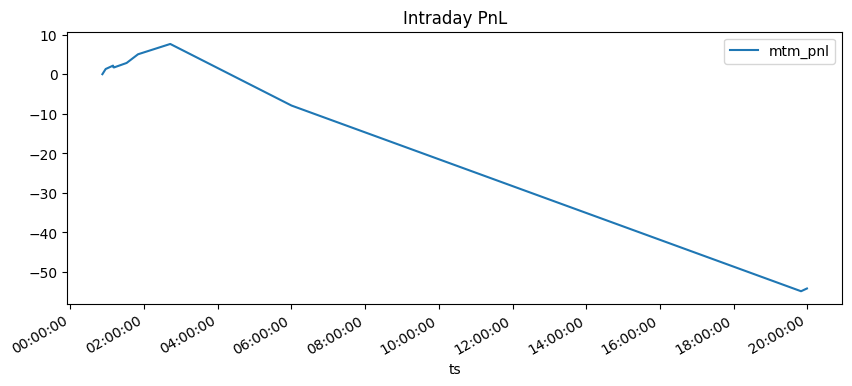

In [95]:
pnl_curve = fills[["ts_us", "mtm_pnl", "mid"]].copy()
pnl_curve["ts"] = pd.to_datetime(pnl_curve.ts_us, unit="us")

ax = pnl_curve.plot(x="ts", y="mtm_pnl", figsize=(10,4), title="Intraday PnL")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()
plt.show()

# pnl_curve.plot(x="ts", y="mtm_pnl", figsize=(10,4), title="Intraday MTM PnL")

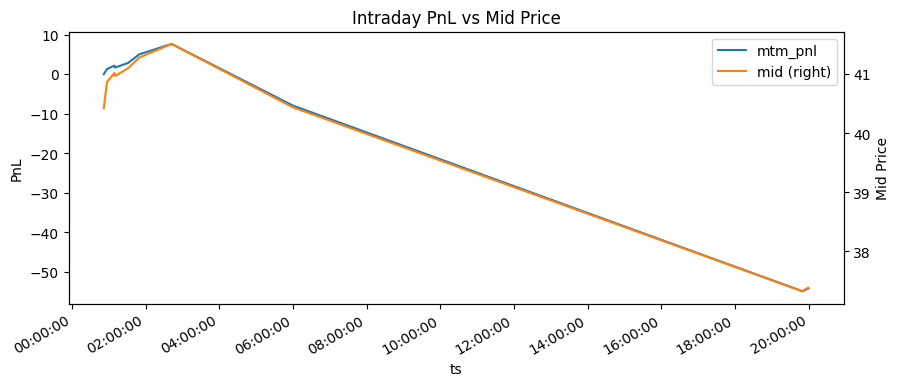

In [66]:
# 1. Prepare the data
pnl_curve = fills[["ts_us", "mtm_pnl", "mid"]].copy()
pnl_curve["ts"] = pd.to_datetime(pnl_curve.ts_us, unit="us")

# 2. Plot both columns, specifying 'mid' for the secondary y-axis
ax = pnl_curve.plot(
    x="ts", 
    y=["mtm_pnl", "mid"], 
    secondary_y=["mid"], 
    figsize=(10, 4), 
    title="Intraday PnL vs Mid Price"
)

# 3. Format the X-axis for readability
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# 4. Optional: Label the axes for clarity
ax.set_ylabel("PnL")
ax.right_ax.set_ylabel("Mid Price")

# Automatically tilt the date labels
plt.gcf().autofmt_xdate()

plt.show()

In [151]:
fills[['side', 'price', 'qty', 'fee', 'cash', 'mid', 'mtm_pnl']].head()

,side,price,qty,fee,cash,mid,mtm_pnl
0,buy,40.881000,0.130000,0.001063,-5.315593,40.884000,-0.000673
1,buy,40.881000,0.130000,0.001063,-10.631186,40.884000,-0.001346
2,buy,40.881000,2.740000,0.022403,-122.667529,40.884000,-0.015529
3,buy,40.670000,2.460000,0.020010,-222.735738,40.673000,-0.661158
4,buy,40.670000,0.540000,0.004392,-244.701931,40.673000,-0.663931


**B) Fill & execution stats**

In [153]:
n_place = (log_df.action == "PLACE").sum()
n_fill = (log_df.action == "FILL").sum()

fill_stats = {
    "regimes_entered": len(reg),
    "regimes_traded": reg.did_trade.sum(),
    "orders_placed": n_place,
    "fills": n_fill,
    "fill_rate": n_fill / max(n_place, 1),
    "avg_episode_hold_ms": episodes.dur_ms.mean(),
    "median_episode_hold_ms": episodes.dur_ms.median(),
}

pd.DataFrame(fill_stats, index=["value"]).T

,value
regimes_entered,1309.000000
regimes_traded,58.000000
orders_placed,114.000000
fills,44.000000
fill_rate,0.385965
avg_episode_hold_ms,156.742552
median_episode_hold_ms,155.000000


**C) Per-episode PnL**

In [164]:
def episode_pnl(ep):
    m = (fills.ts_us >= ep.enter_ts_us) & (fills.ts_us <= ep.exit_ts_us)
    if not m.any():
        return 0.0

    mtm_start = fills.loc[m, "mtm_pnl"].iloc[0]
    mtm_end   = fills.loc[m, "mtm_pnl"].iloc[-1]
    return mtm_end - mtm_start

episodes["episode_pnl"] = episodes.apply(episode_pnl, axis=1)
episodes["episode_pnl"].describe()

count   1309.000000
mean      -0.000148
std        0.002307
min       -0.059535
25%        0.000000
50%        0.000000
75%        0.000000
max        0.000000
Name: episode_pnl, dtype: float64

In [100]:
1309* -0.00014

-0.18325999999999998

**D) Adverse Selection**

In [170]:
quotes_mid = quotes_df[["ts_us"]].copy()
if "mid" in quotes_df.columns:
    quotes_mid["mid"] = quotes_df["mid"].astype(float)
else:
    quotes_mid["mid"] = (quotes_df["best_bid"].astype(float) + quotes_df["best_ask"].astype(float)) / 2

quotes_mid = quotes_mid.sort_values("ts_us").reset_index(drop=True)

fills = fills.sort_values("ts_us").reset_index(drop=True)

horizons_ms = [50, 150, 300]  # add 300 if you want: [10, 50, 150, 300]

for h in horizons_ms:
    # mid at t + h
    tmp = fills[["ts_us"]].copy()
    tmp["ts_us_h"] = tmp["ts_us"] + h * 1000  # ms -> us

    tmp = pd.merge_asof(
        tmp.sort_values("ts_us_h"),
        quotes_mid.rename(columns={"ts_us": "ts_us_q", "mid": f"mid_{h}ms"}).sort_values("ts_us_q"),
        left_on="ts_us_h",
        right_on="ts_us_q",
        direction="backward",
        allow_exact_matches=True
    ).sort_index()

    fills[f"mid_{h}ms"] = tmp[f"mid_{h}ms"].values

    # adverse selection: signed move against our fill
    # buy: mid goes down => negative; so use (mid_future - fill_price)
    # sell: mid goes up => negative; so use (fill_price - mid_future)
    fills[f"as_{h}ms"] = np.where(
        fills["side"].eq("buy"),
        fills[f"mid_{h}ms"] - fills["price"],
        fills["price"] - fills[f"mid_{h}ms"]
    )

# Summary table
as_cols = [f"as_{h}ms" for h in horizons_ms]
fills[as_cols].describe()

,as_50ms,as_150ms,as_300ms
count,44.000000,44.000000,44.000000
mean,-0.001693,-0.002602,-0.003773
std,0.001654,0.004340,0.007101
min,-0.004500,-0.010000,-0.018500
25%,-0.002375,-0.005500,-0.008500
50%,-0.001500,-0.002000,-0.002000
75%,-0.000500,-0.000500,0.001750
max,0.002500,0.008500,0.009500


In [165]:
fills.columns

Index(['ts_us', 'event_i', 'etype', 'action', 'reason', 'spread_bps',
       'med_bps', 'pos', 'enter_thr_bps', 'enter_excess_bps', 'side',
       'order_id', 'price', 'qty', 'fill_source', 'fee', 'cash', 'elapsed_ms',
       'tox_count', 'tox_total', 'tox_net', 'best_bid', 'best_ask',
       'gated_side', 'Q_max', 'old_price', 'new_price', 'ts', 'mid',
       'signed_qty', 'trade_cash', 'net_cash', 'cum_cash', 'position',
       'mtm_pnl', 'fee_bps'],
      dtype='object')

In [159]:
log_df.head(6)

,ts_us,event_i,etype,action,reason,spread_bps,med_bps,pos,enter_thr_bps,enter_excess_bps,side,order_id,price,qty,fill_source,fee,cash,elapsed_ms,tox_count,tox_total,tox_net,best_bid,best_ask,gated_side,Q_max,old_price,new_price,ts
0,1754006462405000,4187,quote,REGIME,enter_regime,1.956756,0.244565,0.000000,1.711952,0.244804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
1,1754006462405000,4187,quote,PLACE,enter_regime,NaN,NaN,0.000000,NaN,NaN,buy,1.000000,40.881000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
2,1754006462405000,4187,quote,PLACE,enter_regime,NaN,NaN,0.000000,NaN,NaN,sell,2.000000,40.887000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.405000+00:00
3,1754006462416000,4188,trade,FILL,NaN,NaN,NaN,0.130000,NaN,NaN,buy,1.000000,40.881000,0.130000,trade_through,0.001063,-5.315593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.416000+00:00
4,1754006462416000,4189,trade,FILL,NaN,NaN,NaN,0.260000,NaN,NaN,buy,1.000000,40.881000,0.130000,trade_through,0.001063,-10.631186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.416000+00:00
5,1754006462416000,4190,trade,FILL,NaN,NaN,NaN,3.000000,NaN,NaN,buy,1.000000,40.881000,2.740000,trade_through,0.022403,-122.667529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-01 00:01:02.416000+00:00


In [158]:
quotes_df[quotes_df['ts_us']>=1754006462405000].head(10)

,ts,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,asks[2].amount,bids[2].price,bids[2].amount,asks[3].price,asks[3].amount,bids[3].price,bids[3].amount,asks[4].price,asks[4].amount,bids[4].price,bids[4].amount,asks[5].price,asks[5].amount,bids[5].price,bids[5].amount,asks[6].price,asks[6].amount,bids[6].price,bids[6].amount,asks[7].price,asks[7].amount,bids[7].price,bids[7].amount,asks[8].price,asks[8].amount,bids[8].price,bids[8].amount,asks[9].price,asks[9].amount,bids[9].price,bids[9].amount,asks[10].price,asks[10].amount,bids[10].price,bids[10].amount,asks[11].price,asks[11].amount,bids[11].price,bids[11].amount,asks[12].price,asks[12].amount,bids[12].price,bids[12].amount,asks[13].price,asks[13].amount,bids[13].price,bids[13].amount,asks[14].price,asks[14].amount,bids[14].price,bids[14].amount,asks[15].price,asks[15].amount,bids[15].price,bids[15].amount,asks[16].price,asks[16].amount,bids[16].price,bids[16].amount,asks[17].price,asks[17].amount,bids[17].price,bids[17].amount,asks[18].price,asks[18].amount,bids[18].price,bids[18].amount,asks[19].price,asks[19].amount,bids[19].price,bids[19].amount,asks[20].price,asks[20].amount,bids[20].price,bids[20].amount,asks[21].price,asks[21].amount,bids[21].price,bids[21].amount,asks[22].price,asks[22].amount,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,ts_us,date,best_ask,best_bid,mid,spread,spread_bps,spread_med_bps
973,2025-08-01 00:01:02.405,binance-futures,HYPEUSDT,1754006462405000,1754006462409171,40.888000,37.340000,40.880000,32.580000,40.890000,13.060000,40.879000,0.900000,40.891000,22.760000,40.878000,31.840000,40.892000,22.400000,40.877000,15.260000,40.893000,16.240000,40.876000,33.270000,40.894000,36.490000,40.875000,153.150000,40.895000,35.120000,40.874000,0.750000,40.896000,37.570000,40.873000,9.780000,40.897000,6.410000,40.872000,0.290000,40.898000,74.660000,40.871000,0.410000,40.899000,32.610000,40.870000,14.890000,40.900000,114.100000,40.869000,91.770000,40.901000,2.590000,40.867000,62.700000,40.902000,138.950000,40.866000,0.130000,40.903000,24.040000,40.865000,21.660000,40.904000,293.170000,40.864000,103.060000,40.905000,70.510000,40.863000,81.060000,40.906000,117.630000,40.862000,417.810000,40.907000,44.700000,40.861000,182.100000,40.908000,131.410000,40.860000,582.510000,40.909000,0.560000,40.859000,1.180000,40.910000,115.850000,40.858000,108.270000,40.911000,122.290000,40.857000,109.450000,40.912000,184.280000,40.856000,272.930000,40.913000,156.470000,40.855000,38.300000,1754006462405000,2025-08-01,40.888000,40.880000,40.884000,0.008000,1.956756,0.244565
974,2025-08-01 00:01:02.456,binance-futures,HYPEUSDT,1754006462456000,1754006462459982,40.877000,27.740000,40.876000,23.820000,40.878000,14.780000,40.875000,153.150000,40.879000,25.810000,40.874000,0.750000,40.880000,12.230000,40.872000,0.290000,40.882000,8.930000,40.871000,0.410000,40.884000,8.930000,40.870000,159.140000,40.885000,13.390000,40.869000,2.720000,40.886000,19.720000,40.867000,15.170000,40.887000,94.520000,40.866000,0.130000,40.888000,16.430000,40.865000,48.600000,40.890000,8.930000,40.864000,0.680000,40.891000,32.860000,40.863000,85.020000,40.892000,9.420000,40.862000,417.810000,40.893000,60.500000,40.861000,144.380000,40.894000,35.910000,40.860000,582.510000,40.895000,163.260000,40.859000,87.140000,40.896000,24.040000,40.858000,108.270000,40.897000,92.890000,40.857000,109.450000,40.898000,70.440000,40.856000,272.930000,40.899000,118.270000,40.855000,38.300000,40.900000,51.260000,40.854000,83.300000,40.901000,2.590000,40.852000,112.260000,40.902000,61.580000,40.851000,481.220000,40.903000,24.040000,40.850000,58.790000,40.904000,348.220000,40.849000,48.150000,1754006462456000,2025-08-01,40.877000,40.876000,40.876500,0.001000,0.244639,0.244606
975,2025-08-01 00:01:02.5

In [161]:
trades_df[trades_df['ts_us']>=1754006462405000].head(10)

,exchange,symbol,timestamp,local_timestamp,id,side,price,amount,ts_us,ts,date
3214,binance-futures,HYPEUSDT,1754006462416000,1754006462419624,63212093,sell,40.880000,0.130000,1754006462416000,2025-08-01 00:01:02.416,2025-08-01
3215,binance-futures,HYPEUSDT,1754006462416000,1754006462419625,63212094,sell,40.880000,0.130000,1754006462416000,2025-08-01 00:01:02.416,2025-08-01
3216,binance-futures,HYPEUSDT,1754006462416000,1754006462419625,63212095,sell,40.880000,22.980000,1754006462416000,2025-08-01 00:01:02.416,2025-08-01
3217,binance-futures,HYPEUSDT,1754006462416000,1754006462419626,63212096,sell,40.879000,0.410000,1754006462416000,2025-08-01 00:01:02.416,2025-08-01
3218,binance-futures,HYPEUSDT,1754006462416000,1754006462419626,63212097,sell,40.879000,0.490000,1754006462416000,2025-08-01 00:01:02.416,2025-08-01
3219,binance-futures,HYPEUSDT,1754006462427000,1754006462432019,63212098,buy,40.880000,5.170000,1754006462427000,2025-08-01 00:01:02.427,2025-08-01
3220,binance-futures,HYPEUSDT,1754006462432000,1754006462435187,63212099,sell,40.879000,2.190000,1754006462432000,2025-08-01 00:01:02.432,2025-08-01
3221,binance-futures,HYPEUSDT,1754006462432000,1754006462435189,63212100,sell,40.879000,0.580000,1754006462432000,2025-08-01 00:01:02.432,2025-08-01
3222,binance-futures,HYPEUSDT,1754006462432000,1754006462435189,63212101,sell,40.879000,0.730000,1754006462432000,2025-08-01 00:01:02.432,2025-08-01
3223,binance-futures,HYPEUSDT,1754006462432000,1754006462435191,63212102,sell,40.879000,2.210000,1754006462432000,2025-08-01 00:01:02.432,2025-08-01


In [168]:
quotes_df.head()

,ts,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,asks[2].amount,bids[2].price,bids[2].amount,asks[3].price,asks[3].amount,bids[3].price,bids[3].amount,asks[4].price,asks[4].amount,bids[4].price,bids[4].amount,asks[5].price,asks[5].amount,bids[5].price,bids[5].amount,asks[6].price,asks[6].amount,bids[6].price,bids[6].amount,asks[7].price,asks[7].amount,bids[7].price,bids[7].amount,asks[8].price,asks[8].amount,bids[8].price,bids[8].amount,asks[9].price,asks[9].amount,bids[9].price,bids[9].amount,asks[10].price,asks[10].amount,bids[10].price,bids[10].amount,asks[11].price,asks[11].amount,bids[11].price,bids[11].amount,asks[12].price,asks[12].amount,bids[12].price,bids[12].amount,asks[13].price,asks[13].amount,bids[13].price,bids[13].amount,asks[14].price,asks[14].amount,bids[14].price,bids[14].amount,asks[15].price,asks[15].amount,bids[15].price,bids[15].amount,asks[16].price,asks[16].amount,bids[16].price,bids[16].amount,asks[17].price,asks[17].amount,bids[17].price,bids[17].amount,asks[18].price,asks[18].amount,bids[18].price,bids[18].amount,asks[19].price,asks[19].amount,bids[19].price,bids[19].amount,asks[20].price,asks[20].amount,bids[20].price,bids[20].amount,asks[21].price,asks[21].amount,bids[21].price,bids[21].amount,asks[22].price,asks[22].amount,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,ts_us,date,best_ask,best_bid,mid,spread,spread_bps,spread_med_bps
0,2025-08-01 00:00:00.149,binance-futures,HYPEUSDT,1754006400149000,1754006401048006,40.824000,10.000000,40.823000,13.170000,40.827000,0.380000,40.822000,5.370000,40.830000,5.230000,40.821000,6.330000,40.832000,7.820000,40.820000,80.230000,40.833000,24.180000,40.819000,12.310000,40.834000,31.380000,40.818000,16.740000,40.835000,28.590000,40.817000,14.840000,40.836000,136.710000,40.816000,35.190000,40.837000,27.880000,40.815000,70.830000,40.838000,138.450000,40.814000,14.970000,40.840000,376.190000,40.813000,18.520000,40.841000,0.540000,40.812000,29.410000,40.842000,144.110000,40.811000,6.740000,40.844000,11822.840000,40.810000,57.810000,40.845000,1.420000,40.809000,6.330000,40.846000,52.910000,40.808000,0.630000,40.847000,80.840000,40.807000,0.560000,40.848000,130.080000,40.806000,2.580000,40.849000,2.990000,40.805000,111.230000,40.850000,188.470000,40.804000,703.620000,40.851000,208.490000,40.803000,375.790000,40.852000,144.250000,40.802000,75.280000,40.853000,15.750000,40.801000,15.330000,40.854000,86.610000,40.800000,75.080000,40.855000,39.370000,40.799000,38.360000,1754006400149000,2025-08-01,40.824000,40.823000,40.823500,0.001000,0.244957,0.244957
1,2025-08-01 00:00:01.777,binance-futures,HYPEUSDT,1754006401777000,1754006401780745,40.829000,0.130000,40.826000,10.100000,40.832000,2.590000,40.825000,1.870000,40.833000,24.180000,40.823000,53.970000,40.834000,5.370000,40.822000,5.370000,40.835000,2.580000,40.821000,6.330000,40.836000,39.100000,40.820000,77.570000,40.837000,27.880000,40.819000,12.310000,40.838000,92.220000,40.818000,6.950000,40.840000,331.410000,40.817000,14.840000,40.841000,0.540000,40.816000,35.190000,40.842000,70.790000,40.815000,70.830000,40.844000,11773.410000,40.814000,14.970000,40.845000,1.420000,40.813000,18.520000,40.846000,173.170000,40.812000,29.410000,40.847000,80.840000,40.811000,6.740000,40.848000,130.080000,40.810000,57.810000,40.849000,3.270000,40.809000,6.330000,40.850000,192.610000,40.808000,0.630000,40.851000,209.180000,40.807000,0.560000,40.852000,148.540000,40.806000,28.760000,40.853000,15.750000,40.805000,111.230000,40.854000,15.260000,40.804000,703.620000,40.855000,39.370000,40.803000,375.790000,40.856000,125.100000,40.802000,75.280000,40.857000,644.230000,40.801000,15.330000,1754006401777000,2025-08-01,40.829000,40.826000,40.827500,0.003000,0.734799,0.734799
2,2025-08-01 00:00:01.830,binance-futu

In [169]:
quotes_df['diff_ms'] = quotes_df['ts_us'].diff() / 1000

# 2. Drop the first row (which is NaN) for plotting
diff_data = quotes_df['diff_ms'].dropna()
diff_data.describe()

count   1333852.000000
mean         64.774671
std          36.936217
min          51.000000
25%          52.000000
50%          53.000000
75%          56.000000
max        1628.000000
Name: diff_ms, dtype: float64

In [171]:
quotes_df[quotes_df['diff_ms']>1000]

,ts,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,asks[2].amount,bids[2].price,bids[2].amount,asks[3].price,asks[3].amount,bids[3].price,bids[3].amount,asks[4].price,asks[4].amount,bids[4].price,bids[4].amount,asks[5].price,asks[5].amount,bids[5].price,bids[5].amount,asks[6].price,asks[6].amount,bids[6].price,bids[6].amount,asks[7].price,asks[7].amount,bids[7].price,bids[7].amount,asks[8].price,asks[8].amount,bids[8].price,bids[8].amount,asks[9].price,asks[9].amount,bids[9].price,bids[9].amount,asks[10].price,asks[10].amount,bids[10].price,bids[10].amount,asks[11].price,asks[11].amount,bids[11].price,bids[11].amount,asks[12].price,asks[12].amount,bids[12].price,bids[12].amount,asks[13].price,asks[13].amount,bids[13].price,bids[13].amount,asks[14].price,asks[14].amount,bids[14].price,bids[14].amount,asks[15].price,asks[15].amount,bids[15].price,bids[15].amount,asks[16].price,asks[16].amount,bids[16].price,bids[16].amount,asks[17].price,asks[17].amount,bids[17].price,bids[17].amount,asks[18].price,asks[18].amount,bids[18].price,bids[18].amount,asks[19].price,asks[19].amount,bids[19].price,bids[19].amount,asks[20].price,asks[20].amount,bids[20].price,bids[20].amount,asks[21].price,asks[21].amount,bids[21].price,bids[21].amount,asks[22].price,asks[22].amount,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,ts_us,date,best_ask,best_bid,mid,spread,spread_bps,spread_med_bps,diff_ms
1,2025-08-01 00:00:01.777,binance-futures,HYPEUSDT,1754006401777000,1754006401780745,40.829000,0.130000,40.826000,10.100000,40.832000,2.590000,40.825000,1.870000,40.833000,24.180000,40.823000,53.970000,40.834000,5.370000,40.822000,5.370000,40.835000,2.580000,40.821000,6.330000,40.836000,39.100000,40.820000,77.570000,40.837000,27.880000,40.819000,12.310000,40.838000,92.220000,40.818000,6.950000,40.840000,331.410000,40.817000,14.840000,40.841000,0.540000,40.816000,35.190000,40.842000,70.790000,40.815000,70.830000,40.844000,11773.410000,40.814000,14.970000,40.845000,1.420000,40.813000,18.520000,40.846000,173.170000,40.812000,29.410000,40.847000,80.840000,40.811000,6.740000,40.848000,130.080000,40.810000,57.810000,40.849000,3.270000,40.809000,6.330000,40.850000,192.610000,40.808000,0.630000,40.851000,209.180000,40.807000,0.560000,40.852000,148.540000,40.806000,28.760000,40.853000,15.750000,40.805000,111.230000,40.854000,15.260000,40.804000,703.620000,40.855000,39.370000,40.803000,375.790000,40.856000,125.100000,40.802000,75.280000,40.857000,644.230000,40.801000,15.330000,1754006401777000,2025-08-01,40.829000,40.826000,40.827500,0.003000,0.734799,0.734799,1628.000000
268777,2025-08-01 05:05:03.551,binance-futures,HYPEUSDT,1754024703551000,1754024703553084,40.492000,125.620000,40.491000,87.370000,40.495000,15.480000,40.490000,0.550000,40.496000,26.970000,40.489000,0.410000,40.497000,32.910000,40.488000,0.400000,40.498000,69.350000,40.486000,1.130000,40.499000,72.330000,40.485000,10.280000,40.500000,71.910000,40.484000,24.440000,40.501000,132.670000,40.482000,15.640000,40.502000,52.650000,40.481000,1.640000,40.503000,117.930000,40.480000,0.660000,40.504000,30.300000,40.479000,15.840000,40.505000,189.070000,40.478000,0.140000,40.506000,15.380000,40.477000,116.180000,40.507000,33.720000,40.476000,615.710000,40.508000,30.940000,40.475000,69.590000,40.509000,120.190000,40.474000,52.160000,40.510000,30.850000,40.473000,93.210000,40.511000,52.040000,40.472000,25.280000,40.512000,15.240000,40.471000,16.870000,40.513000,228.030000,40.470000,146.730000,40.514000,104.880000,40.469000,371.220000,40.515000,267.500000,40.468000,66.200000,40.516000,108.790000,40.467000,188.510000,40.518000,106.980000,40.466000,96.000000,40.519000,505.810000,40.465000,126.900000,1754024703551000,2025-08-01,40.492000,40.491000,40.491500,0.001000,0.246965,0.246965,1062